<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_VGG_Pretrained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model_VGG_Pretrained
VGG16 with Batch Normalization, fine-tuned from ImageNet weights on VWW using
three-phase progressive unfreezing.

**Three-phase protocol:**
- Phase 1 (epochs 1–9): backbone frozen, train head only at lr=3e-4
- Phase 2 (epochs 10–19): unfreeze features[24:] at lr=1e-4
- Phase 3 (epochs 20–30): unfreeze all features at lr=3e-5

**Note:** VGG16-BN has ~138M parameters — heavily over-parameterized for a
7,000-image binary task. Compare against `Model_VGG.ipynb` (scratch) to isolate
the effect of pretrained weights.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ─────────────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import VGG_Pretrained, count_params, model_size_mb
from utils.train   import setup_device, set_seed, evaluate, train_multi_seed, plot_history

device = setup_device(seed=41)

Device: cuda


In [3]:
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64


In [4]:
SAVE_DIR = "/content/drive/My Drive/stm32-thesis/checkpoints"

In [5]:
# ── Parameter count before training ─────────────────────────────────
model_tmp = VGG_Pretrained().to(device)
total, trainable = count_params(model_tmp)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  (head only at start)")
print(f"Model size      : {model_size_mb(model_tmp):.1f} MB")
del model_tmp

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:03<00:00, 157MB/s]


Total params    : 27,634,626
Trainable params: 12,911,490  (head only at start)
Model size      : 110.6 MB


In [6]:
results, best = train_multi_seed(
    model_fn     = VGG_Pretrained,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63, 74, 85],
    save_dir     = SAVE_DIR,
    name_prefix  = "vgg_pretrained",
    pretrained   = True,           # ← uses train_model_three_phase internally
    # Pretrained hyperparameters
    epochs          = 30,
    lr_phase1       = 3e-4,
    lr_phase2       = 1e-4,
    lr_phase3       = 3e-5,
    phase2_epoch    = 10,
    phase3_epoch    = 20,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 10,
)


Seed 41
[P1] Epoch   1/30 | LR 0.000291 | Train 74.87% | Val 80.53% ✅
[P1] Epoch   2/30 | LR 0.000265 | Train 78.43% | Val 79.27%
[P1] Epoch   3/30 | LR 0.000225 | Train 80.06% | Val 81.67% ✅
[P1] Epoch   4/30 | LR 0.000176 | Train 80.56% | Val 81.40%
[P1] Epoch   5/30 | LR 0.000124 | Train 81.03% | Val 81.60%
[P1] Epoch   6/30 | LR 0.000075 | Train 82.23% | Val 81.67%
[P1] Epoch   7/30 | LR 0.000035 | Train 82.06% | Val 81.87% ✅
[P1] Epoch   8/30 | LR 0.000009 | Train 82.53% | Val 81.13%
[P1] Epoch   9/30 | LR 0.000000 | Train 83.17% | Val 81.20%

── Phase 2: partial unfreeze (epoch 10) ──
🔥 VGG16-BN: unfroze features[24:]
[P2] Epoch  10/30 | LR 0.000098 | Train 84.67% | Val 86.20% ✅
[P2] Epoch  11/30 | LR 0.000090 | Train 89.59% | Val 87.00% ✅
[P2] Epoch  12/30 | LR 0.000079 | Train 91.31% | Val 87.00%
[P2] Epoch  13/30 | LR 0.000065 | Train 93.33% | Val 87.67% ✅
[P2] Epoch  14/30 | LR 0.000050 | Train 95.01% | Val 87.80% ✅
[P2] Epoch  15/30 | LR 0.000035 | Train 95.84% | Val 87.40%

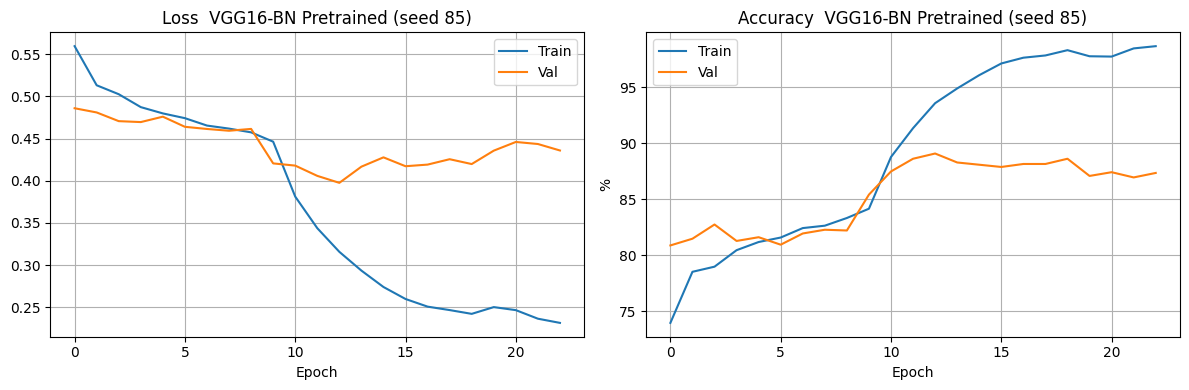

Best: 89.07% @ epoch 13  (7.3 min)

VGG16-BN Pretrained  |  Mean: 88.24% ± 0.60%  |  Best: 89.07% (seed 85)
Best checkpoint: /content/drive/My Drive/stm32-thesis/checkpoints/vgg_pretrained_seed_85.pth


In [7]:
plot_history(best, title=f"VGG16-BN Pretrained (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nVGG16-BN Pretrained  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%  |  Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Best checkpoint: {best['save_path']}")

## Scratch vs Pretrained comparison
Run `Model_VGG.ipynb` first, then come back here to compare.

In [8]:
# ── Compare scratch vs pretrained val accuracy ───────────────────────
# Load best scratch VGG checkpoint and evaluate on val set
SCRATCH_CKPT = f"{SAVE_DIR}/vggstyle_seed_85.pth"   # adjust seed

from utils.models import VWW_VGGStyle

if os.path.exists(SCRATCH_CKPT):
    scratch_model = VWW_VGGStyle().to(device)
    scratch_model.load_state_dict(torch.load(SCRATCH_CKPT, map_location=device))
    scratch_acc = evaluate(scratch_model, val_loader, device)

    pretrained_model = VGG_Pretrained().to(device)
    pretrained_model.load_state_dict(torch.load(best["save_path"], map_location=device))
    pretrained_acc = evaluate(pretrained_model, val_loader, device)

    print("="*50)
    print(f"VGG scratch    val acc: {scratch_acc*100:.2f}%")
    print(f"VGG pretrained val acc: {pretrained_acc*100:.2f}%")
    print(f"Pretrained gain       : {(pretrained_acc - scratch_acc)*100:+.2f}%")
    print("="*50)
else:
    print("⚠️  Run Model_VGG.ipynb first to get the scratch checkpoint")

VGG scratch    val acc: 78.67%
VGG pretrained val acc: 89.07%
Pretrained gain       : +10.40%
